# Advanced Statistical EDA  Stock Market Dataset
### Descriptive Stats · Distributions · Hypothesis Testing · Regression · Dimensionality Reduction · Clustering · Advanced Time Series

## Contents
| Part | Topic |
|---|---|
| A | Descriptive statistics, normal distribution check, Central Limit Theorem demo |
| B | Hypothesis testing: t-tests, ANOVA, Chi-square, non-parametric tests |
| C | Correlation, linear regression (CAPM beta), regularization (Ridge/Lasso), PCA |
| D | K-Means clustering (volatility/return regimes) |
| E | Moving-average smoothing, STL decomposition |

---

## Setup 

In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RAW_PATH = "cleaned_stock_data.csv"
raw = pd.read_csv(RAW_PATH, header=[0, 1], skiprows=[2])
raw.columns = [f"{a}_{b}" if b != "Ticker" else "Date" for a, b in raw.columns]
raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)

TICKERS = ["AAPL", "MSFT", "SPY"]
data = {}
for t in TICKERS:
    sub = raw[["Date"] + [f"{c}_{t}" for c in ["Open", "High", "Low", "Close", "Volume"]]].copy()
    sub.columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
    sub["Return"] = sub["Close"].pct_change()
    sub["LogReturn"] = np.log(sub["Close"]).diff()
    data[t] = sub

PRIMARY = "AAPL"   
df = data[PRIMARY].copy()

returns = pd.DataFrame({t: data[t]["Return"] for t in TICKERS}).dropna().reset_index(drop=True)
returns.head()

,AAPL,MSFT,SPY
0,0.002263,0.002584,0.005536
1,0.019597,0.022275,0.007643
2,0.014719,0.000036,-0.001821
3,0.017955,0.008175,0.003534
4,-0.009200,-0.008967,-0.008148


## Part A.1 — Descriptive Statistics
Mean, spread, and shape (skew/kurtosis) of price and returns for the primary ticker.
Skew and kurtosis matter here specifically because they set up the normality discussion
right below: real daily stock returns are almost never perfectly normal.

In [23]:
desc = df[["Open","High","Low","Close","Volume","Return"]].describe()
print(desc)
print(f"\nReturn skewness: {df['Return'].skew():.3f}   (0 = symmetric)")
print(f"Return kurtosis (excess): {df['Return'].kurt():.3f}   (0 = normal-like tails; >0 = fat tails)")

              Open         High          Low        Close        Volume  \
count  1254.000000  1254.000000  1254.000000  1254.000000  1.254000e+03   
mean    193.417091   195.532880   191.509875   193.593822  6.531308e+07   
std      44.754468    45.112575    44.385245    44.716047  2.874143e+07   
min     123.907030   125.637665   122.097750   122.933556  1.791060e+07   
25%     156.502157   158.730800   154.276045   156.210093  4.578078e+07   
50%     182.044390   184.130755   180.638115   182.407790  5.728620e+07   
75%     226.519098   228.467955   224.232818   226.514893  7.740915e+07   
max     314.180000   317.400000   309.650000   315.200000  3.186799e+08   

            Return  
count  1253.000000  
mean      0.000748  
std       0.017450  
min      -0.092456  
25%      -0.007770  
50%       0.001069  
75%       0.009523  
max       0.153288  

Return skewness: 0.426   (0 = symmetric)
Return kurtosis (excess): 6.812   (0 = normal-like tails; >0 = fat tails)


## Part A.2 — Normal Distribution Check
Two standard normality tests on daily returns:
- **Jarque-Bera**: based on sample skewness & kurtosis.
- **Shapiro-Wilk**: general-purpose normality test (most powerful for small-to-medium samples).

Both share H0 = "the data is normally distributed". A small p-value (<0.05) rejects
normality. We also visualize with a histogram (return distribution vs. a fitted normal curve)
and a Q-Q plot (if points hug the diagonal, the data is normal — deviations at the tails
indicate the "fat tails" common in financial returns).

Jarque-Bera:  stat=2437.62, p-value=0.000000
Shapiro-Wilk: stat=0.9454, p-value=0.000000
Both reject H0 at typical financial-return sample sizes -> returns are NOT normally distributed (fat tails).


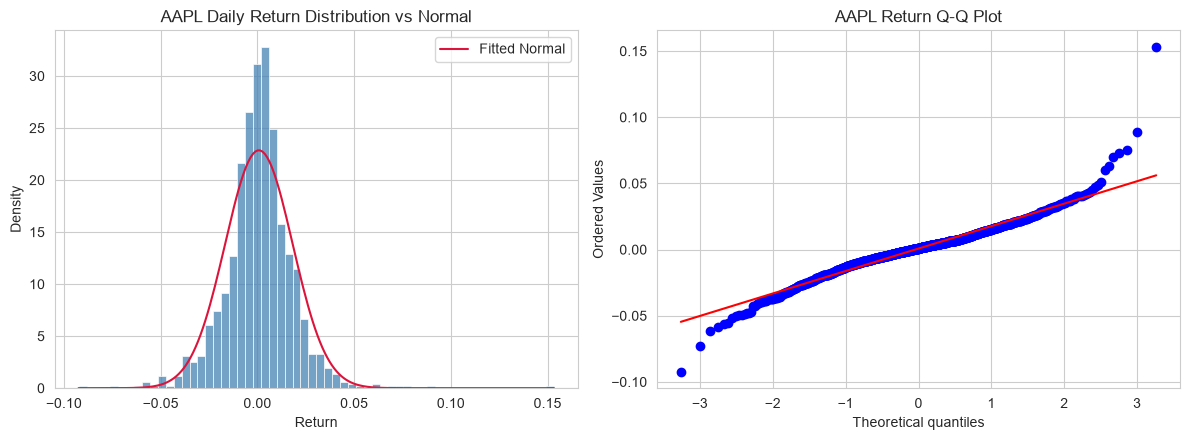

In [24]:
ret = df["Return"].dropna()

jb_stat, jb_p = stats.jarque_bera(ret)
sh_stat, sh_p = stats.shapiro(ret.sample(min(len(ret), 5000), random_state=1))
print(f"Jarque-Bera:  stat={jb_stat:.2f}, p-value={jb_p:.6f}")
print(f"Shapiro-Wilk: stat={sh_stat:.4f}, p-value={sh_p:.6f}")
print("Both reject H0 at typical financial-return sample sizes -> returns are NOT normally distributed (fat tails).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(ret, kde=False, stat="density", bins=60, ax=axes[0], color="steelblue")
x = np.linspace(ret.min(), ret.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color="crimson", label="Fitted Normal")
axes[0].set_title(f"{PRIMARY} Daily Return Distribution vs Normal")
axes[0].legend()

stats.probplot(ret, dist="norm", plot=axes[1])
axes[1].set_title(f"{PRIMARY} Return Q-Q Plot")
plt.tight_layout()
plt.show()

## Part A.3 — Central Limit Theorem (CLT) Demonstration
The CLT says: even though the individual daily returns are *not* normal (confirmed above),
the **sampling distribution of the mean** return becomes approximately normal as the sample
size `n` grows. We demonstrate this directly: repeatedly draw random samples of size `n` from
the actual return series, compute each sample's mean, and look at how the skewness of that
collection of means shrinks toward 0 as `n` increases.

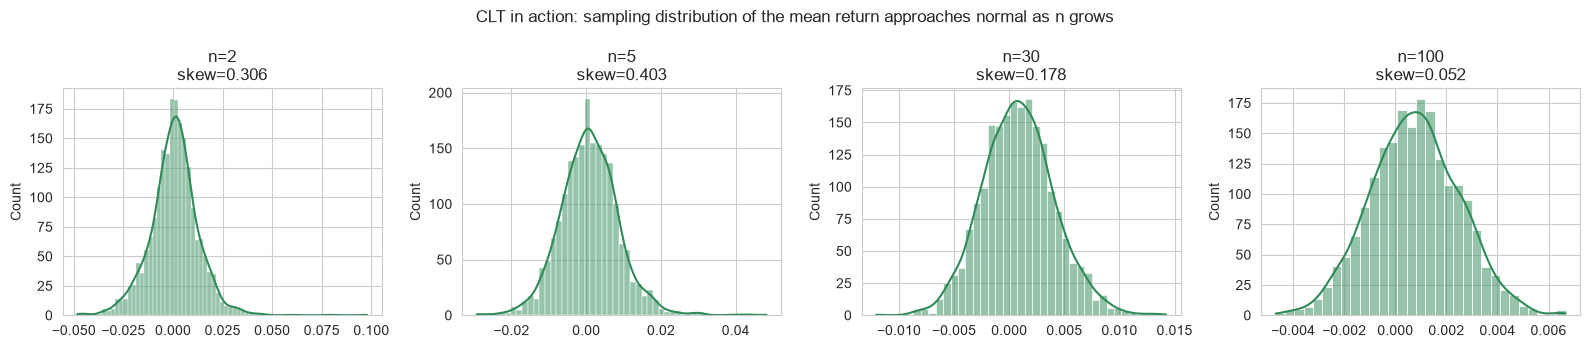

In [25]:
np.random.seed(42)
sample_sizes = [2, 5, 30, 100]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, sample_sizes):
    means = [ret.sample(n, replace=True).mean() for _ in range(2000)]
    sk = stats.skew(means)
    sns.histplot(means, kde=True, ax=ax, color="seagreen")
    ax.set_title(f"n={n}\nskew={sk:.3f}")
plt.suptitle("CLT in action: sampling distribution of the mean return approaches normal as n grows")
plt.tight_layout()
plt.show()

## Part B.1 — Hypothesis Testing: t-tests
- **One-sample t-test**: is the average daily return significantly different from 0?
- **Two-sample (independent) t-test**: is AAPL's average return significantly different
  from SPY's (i.e. does the individual stock behave differently from the market benchmark)?

In [26]:
t1, p1 = stats.ttest_1samp(data[PRIMARY]["Return"].dropna(), 0)
print(f"One-sample t-test ({PRIMARY} mean return vs 0): t={t1:.3f}, p={p1:.4f}")
print("  ->", "Significant" if p1 < 0.05 else "NOT significant", "at alpha=0.05")

t2, p2 = stats.ttest_ind(data["AAPL"]["Return"].dropna(), data["SPY"]["Return"].dropna(), equal_var=False)
print(f"\nTwo-sample t-test (AAPL vs SPY daily returns): t={t2:.3f}, p={p2:.4f}")
print("  ->", "Significant" if p2 < 0.05 else "NOT significant", "at alpha=0.05")

One-sample t-test (AAPL mean return vs 0): t=1.517, p=0.1296
  -> NOT significant at alpha=0.05

Two-sample t-test (AAPL vs SPY daily returns): t=0.340, p=0.7337
  -> NOT significant at alpha=0.05


## Part B.2 — ANOVA (comparing more than 2 groups)
- **Across tickers**: do AAPL, MSFT, and SPY have significantly different mean daily returns?
- **Across day-of-week**: does the primary ticker's mean return differ by weekday
  (5 groups — this formally tests what Notebook 1's seasonality bar chart only showed visually)?

In [27]:
f1, pf1 = stats.f_oneway(data["AAPL"]["Return"].dropna(), data["MSFT"]["Return"].dropna(), data["SPY"]["Return"].dropna())
print(f"One-way ANOVA (AAPL vs MSFT vs SPY returns): F={f1:.3f}, p={pf1:.4f}")
print("  ->", "Significant" if pf1 < 0.05 else "NOT significant", "at alpha=0.05")

df["DOW"] = df["Date"].dt.day_name()
groups = [g["Return"].dropna().values for _, g in df.groupby("DOW")]
f2, pf2 = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA ({PRIMARY} returns across day-of-week): F={f2:.3f}, p={pf2:.4f}")
print("  ->", "Significant" if pf2 < 0.05 else "NOT significant", "at alpha=0.05")

One-way ANOVA (AAPL vs MSFT vs SPY returns): F=0.142, p=0.8679
  -> NOT significant at alpha=0.05

One-way ANOVA (AAPL returns across day-of-week): F=0.901, p=0.4624
  -> NOT significant at alpha=0.05


## Part B.3 — Chi-Square Test of Independence
Chi-square needs *categorical* data, so we bin returns into **Up day / Down day**, cross-tab
against **day-of-week**, and test whether the two are independent.
H0: whether a day is Up/Down is independent of which weekday it is.

In [28]:
df["UpDay"] = (df["Return"] > 0).astype(int)
contingency = pd.crosstab(df["DOW"], df["UpDay"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print("Contingency table (rows=weekday, columns=Down(0)/Up(1)):")
print(contingency)
print(f"\nChi-square test: chi2={chi2:.3f}, dof={dof}, p={p_chi:.4f}")
print("  ->", "Significant (NOT independent)" if p_chi < 0.05 else "NOT significant (consistent with independence)", "at alpha=0.05")

Contingency table (rows=weekday, columns=Down(0)/Up(1)):
UpDay        0    1
DOW                
Friday     121  132
Monday     108  125
Thursday   127  124
Tuesday    115  144
Wednesday  118  140

Chi-square test: chi2=2.280, dof=4, p=0.6844
  -> NOT significant (consistent with independence) at alpha=0.05


## Part B.4 — Non-Parametric Tests
Since Part A.2 showed returns are **not normal**, t-tests/ANOVA technically assume something
that's violated here (though both are fairly robust to non-normality at these sample sizes).
The non-parametric equivalents make no distributional assumption at all:
- **Mann-Whitney U** — non-parametric alternative to the 2-sample t-test (AAPL vs SPY).
- **Kruskal-Wallis** — non-parametric alternative to one-way ANOVA (AAPL vs MSFT vs SPY).

In [29]:
u_stat, p_u = stats.mannwhitneyu(data["AAPL"]["Return"].dropna(), data["SPY"]["Return"].dropna())
print(f"Mann-Whitney U (AAPL vs SPY returns): U={u_stat:.1f}, p={p_u:.4f}")

h_stat, p_h = stats.kruskal(data["AAPL"]["Return"].dropna(), data["MSFT"]["Return"].dropna(), data["SPY"]["Return"].dropna())
print(f"Kruskal-Wallis (AAPL vs MSFT vs SPY returns): H={h_stat:.3f}, p={p_h:.4f}")
print("\nBoth agree with the parametric tests above (NOT significant) -> the non-normality doesn't change the conclusion here.")

Mann-Whitney U (AAPL vs SPY returns): U=792381.0, p=0.6838
Kruskal-Wallis (AAPL vs MSFT vs SPY returns): H=0.410, p=0.8148

Both agree with the parametric tests above (NOT significant) -> the non-normality doesn't change the conclusion here.


## Part C.1 — Correlation
Pearson (linear) and Spearman (rank/monotonic — more appropriate given non-normal returns)
correlation between the three tickers' daily returns.

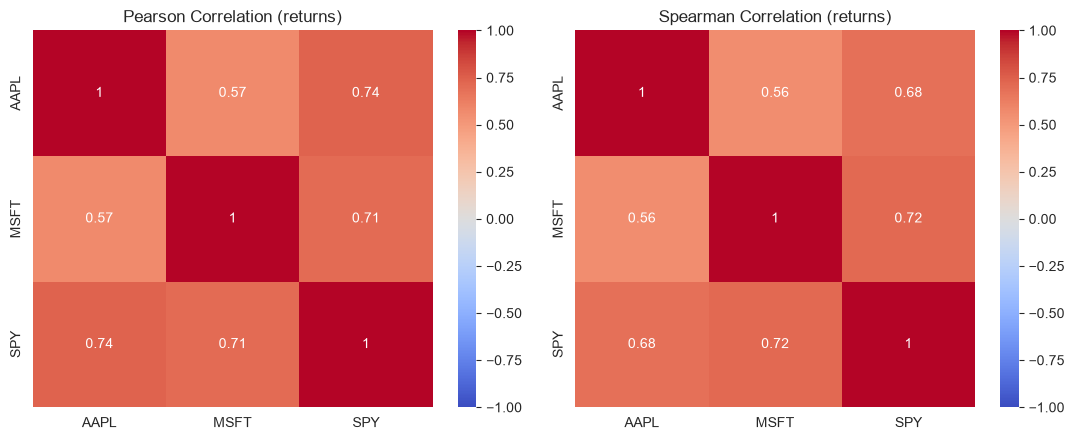

       AAPL   MSFT    SPY
AAPL  1.000  0.573  0.741
MSFT  0.573  1.000  0.709
SPY   0.741  0.709  1.000


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(returns.corr(method="pearson"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Correlation (returns)")
sns.heatmap(returns.corr(method="spearman"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Correlation (returns)")
plt.tight_layout()
plt.show()
print(returns.corr().round(3))

## Part C.2 — Linear Regression: CAPM Market Model
Classic finance application of linear regression: regress a stock's returns on the market
benchmark's returns (SPY here, as a proxy for "the market").
`AAPL_return = alpha + beta * SPY_return + error`
- **beta > 1** → AAPL moves more than the market (more aggressive/volatile).
- **beta < 1** → AAPL moves less than the market (more defensive).
- **alpha** → average return unexplained by the market (stock-specific edge, near 0 typically).

Beta (AAPL vs SPY): 1.195
Alpha (intercept):  0.00009
R-squared:          0.549


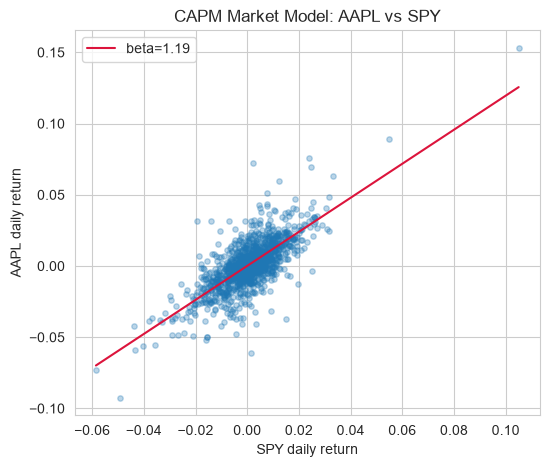

In [31]:
from sklearn.linear_model import LinearRegression

X = returns[["SPY"]].values
y = returns["AAPL"].values
capm = LinearRegression().fit(X, y)
print(f"Beta (AAPL vs SPY): {capm.coef_[0]:.3f}")
print(f"Alpha (intercept):  {capm.intercept_:.5f}")
print(f"R-squared:          {capm.score(X, y):.3f}")

plt.figure(figsize=(6,5))
plt.scatter(returns["SPY"], returns["AAPL"], alpha=0.3, s=15)
xs = np.linspace(returns["SPY"].min(), returns["SPY"].max(), 100)
plt.plot(xs, capm.predict(xs.reshape(-1,1)), color="crimson", label=f"beta={capm.coef_[0]:.2f}")
plt.xlabel("SPY daily return"); plt.ylabel("AAPL daily return")
plt.title("CAPM Market Model: AAPL vs SPY"); plt.legend()
plt.show()

## Part C.3 — Regularization: Ridge & Lasso Regression
We build a small multi-feature model — AAPL's return explained by lagged AAPL/MSFT/SPY returns
plus same-day MSFT/SPY returns — and compare plain OLS against **Ridge** (L2, shrinks all
coefficients) and **Lasso** (L1, can zero out coefficients entirely — automatic feature
selection). This matters here because the lagged features are weak/noisy predictors and
MSFT/SPY are correlated with each other (multicollinearity) — exactly the situation
regularization is designed for.

**Caveat:** the same-day SPY/MSFT coefficients mostly capture *contemporaneous* co-movement
(all three move together intraday), not genuine next-day predictive power — worth noting if
you present this as "prediction."

In [32]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

full = pd.DataFrame({
    "AAPL_lag1": returns["AAPL"].shift(1),
    "MSFT_lag1": returns["MSFT"].shift(1),
    "SPY_lag1":  returns["SPY"].shift(1),
    "SPY": returns["SPY"],
    "MSFT": returns["MSFT"],
    "AAPL": returns["AAPL"],
}).dropna().reset_index(drop=True)

feat_cols = ["AAPL_lag1","MSFT_lag1","SPY_lag1","SPY","MSFT"]
Xtr, Xte, ytr, yte = train_test_split(full[feat_cols], full["AAPL"], test_size=0.2, shuffle=False)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

models = {
    "OLS":   LinearRegression().fit(Xtr_s, ytr),
    "Ridge": Ridge(alpha=1.0).fit(Xtr_s, ytr),
    "Lasso": Lasso(alpha=0.001).fit(Xtr_s, ytr),
}
rows = []
for name, m in models.items():
    r2 = r2_score(yte, m.predict(Xte_s))
    rows.append([name, r2] + list(np.round(m.coef_, 4)))
pd.DataFrame(rows, columns=["Model","Test R2"] + feat_cols)

,Model,Test R2,AAPL_lag1,MSFT_lag1,SPY_lag1,SPY,MSFT
0,OLS,0.152315,0.0018,0.0,-0.0013,0.0122,0.0025
1,Ridge,0.152328,0.0018,0.0,-0.0013,0.0122,0.0025
2,Lasso,0.179607,0.0000,0.0,0.0000,0.0117,0.0018


## Part C.4 — PCA (Principal Component Analysis)
PCA on the 3 tickers' standardized returns tells us how much of the day-to-day movement is
shared ("one common market factor") vs. ticker-specific.

Explained variance ratio by component: [0.784 0.143 0.073]
PC1 alone explains 78.4% of the variance.
PC1 loadings (AAPL, MSFT, SPY): [0.568 0.558 0.605]
-> Roughly equal, same-sign loadings on PC1 = a single 'market factor' drives most co-movement across all three tickers.


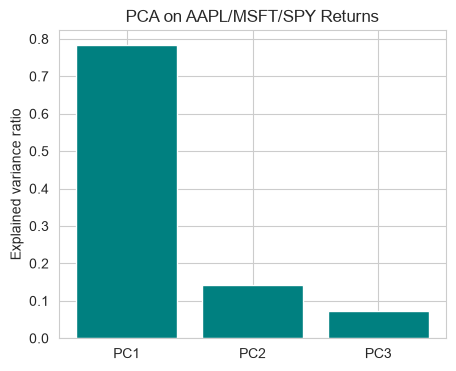

In [33]:
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(returns[TICKERS])
pca = PCA(n_components=3).fit(Xs)

print("Explained variance ratio by component:", np.round(pca.explained_variance_ratio_, 3))
print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% of the variance.")
print("PC1 loadings (AAPL, MSFT, SPY):", np.round(pca.components_[0], 3))
print("-> Roughly equal, same-sign loadings on PC1 = a single 'market factor' drives most co-movement across all three tickers.")

plt.figure(figsize=(5,4))
plt.bar(["PC1","PC2","PC3"], pca.explained_variance_ratio_, color="teal")
plt.ylabel("Explained variance ratio")
plt.title("PCA on AAPL/MSFT/SPY Returns")
plt.show()

## Part D — K-Means Clustering: Market Regime Detection
Cluster individual trading days (for the primary ticker) using two features — **daily return**
and **rolling 20-day volatility** — into 3 unsupervised regimes. The idea: days naturally group
into things like "calm," "rallying," and "stressed/panic" without us labeling them in advance.

           Return  RollVol20  n_days
Cluster                             
0       -0.017913   0.032385      89
1       -0.005152   0.013615     792
2        0.018561   0.017685     353


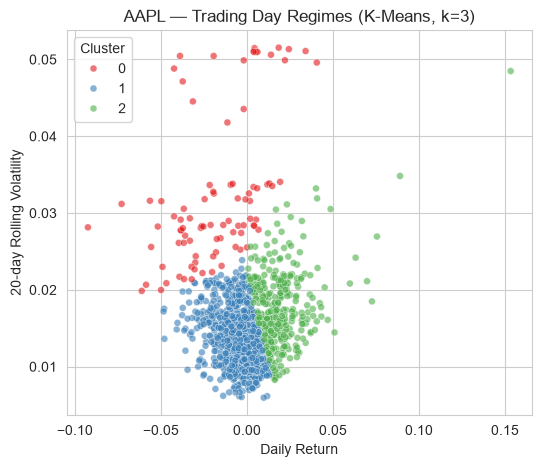

In [34]:
from sklearn.cluster import KMeans

df["RollVol20"] = df["Return"].rolling(20).std()
feat = df[["Date","Return","RollVol20"]].dropna().reset_index(drop=True)
Xc = StandardScaler().fit_transform(feat[["Return","RollVol20"]])

km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xc)
feat["Cluster"] = km.labels_

summary = feat.groupby("Cluster")[["Return","RollVol20"]].mean()
summary["n_days"] = feat["Cluster"].value_counts()
print(summary)

plt.figure(figsize=(6,5))
sns.scatterplot(data=feat, x="Return", y="RollVol20", hue="Cluster", palette="Set1", alpha=0.6, s=25)
plt.title(f"{PRIMARY} — Trading Day Regimes (K-Means, k=3)")
plt.xlabel("Daily Return"); plt.ylabel("20-day Rolling Volatility")
plt.show()

## Part E.1 — Moving Average Smoothing (Weighted MA)
Notebook 1 already covered SMA/EMA for the crossover strategy — here we use a **Weighted
Moving Average (WMA)**, which weights recent days more than SMA but less aggressively than
EMA, purely to produce a smoothed series as a clean input for the decomposition step below.

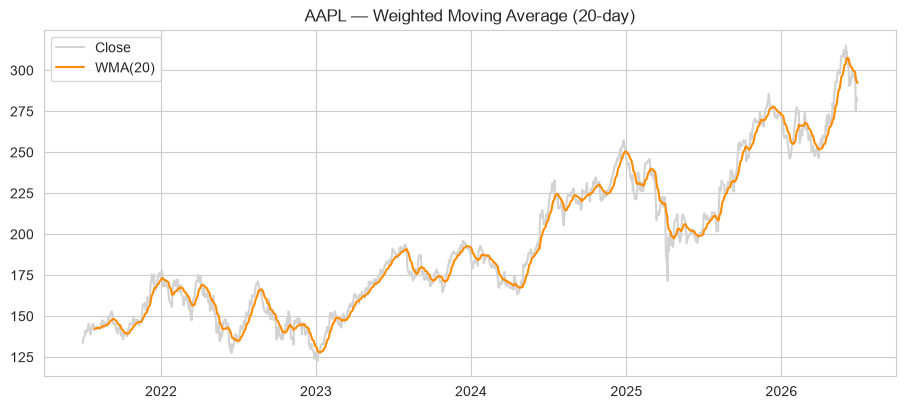

In [35]:
def wma(series, window):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

df["WMA20"] = wma(df["Close"], 20)

plt.figure(figsize=(11,4.5))
plt.plot(df["Date"], df["Close"], color="lightgrey", label="Close")
plt.plot(df["Date"], df["WMA20"], color="darkorange", label="WMA(20)")
plt.title(f"{PRIMARY} — Weighted Moving Average (20-day)")
plt.legend(); plt.show()

## Part E.2 — Time Series Decomposition (STL)
STL (Seasonal-Trend decomposition using LOESS) splits the price series into **trend +
seasonal + residual** components. We use a 252-trading-day period (approximating one
calendar year) since daily stock prices don't have a strong weekly seasonal cycle the way
retail sales or web traffic do — the "seasonal" component here is better thought of as a
slow, repeating annual pattern rather than a strict calendar effect.

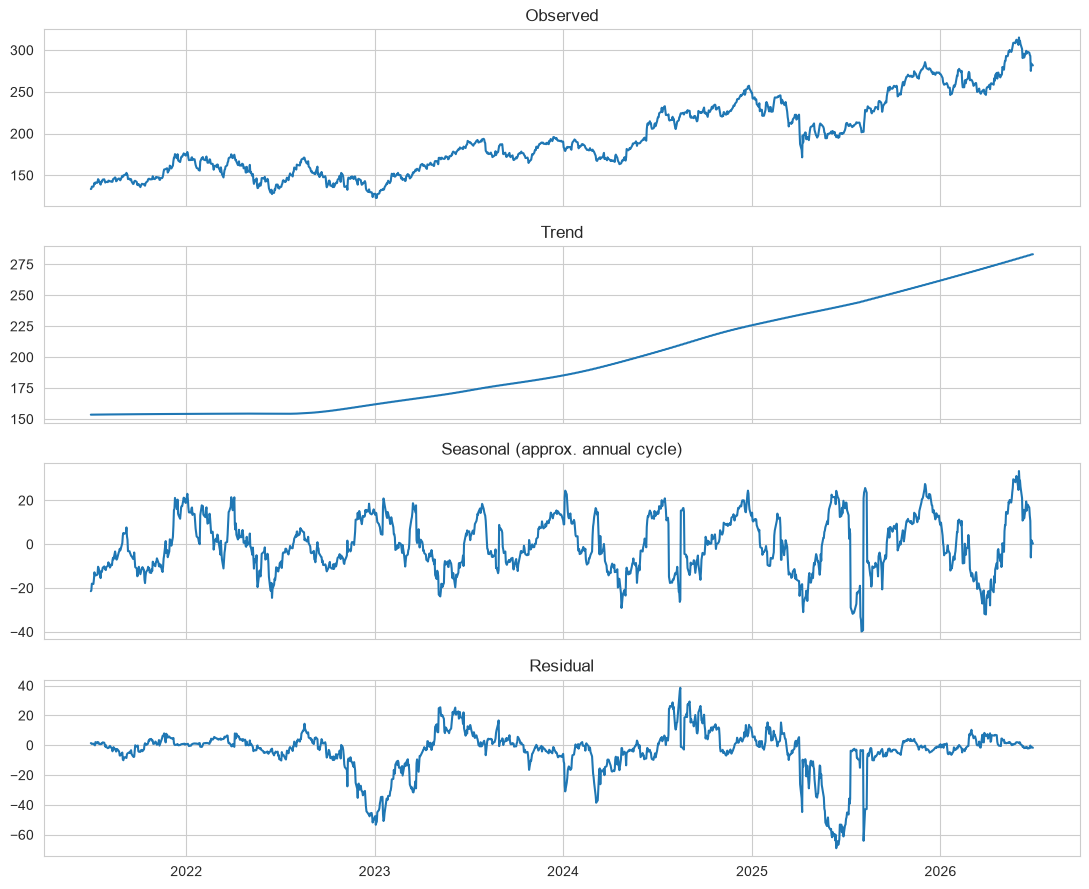

Residual std: 15.150  (smaller = trend+seasonal explain more of the price path)


In [36]:
from statsmodels.tsa.seasonal import STL

ts = df.set_index("Date")["Close"].asfreq("B").ffill()
stl = STL(ts, period=252, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(ts.index, ts.values); axes[0].set_title("Observed")
axes[1].plot(ts.index, stl.trend); axes[1].set_title("Trend")
axes[2].plot(ts.index, stl.seasonal); axes[2].set_title("Seasonal (approx. annual cycle)")
axes[3].plot(ts.index, stl.resid); axes[3].set_title("Residual")
plt.tight_layout(); plt.show()

print(f"Residual std: {stl.resid.std():.3f}  (smaller = trend+seasonal explain more of the price path)")